# Project 2: Healthcare Data Preparation for Patient Analytics

---
### **Student Details & Project Information**:
* **Project Number**: Project 2
* **Student Name**: Akshad Viresh Makhana
* **PRN**: 2124UDSM1007
* **Department**: TY AIDS(A)
* **Project Title**: Healthcare Data Preparation for Patient Analytics
* **Dataset**: Diabetes 130-US Hospitals for years 1999–2008 (UCI ID: 296)
* **GitHub Repository**: [https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics](https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics)

---
### **Objective**:
* Perform healthcare data cleaning, transformations, and feature engineering.
* Generate a clean, machine-learning-ready patient dataset and technical reports.

---
### **Deliverables Checklist**:
1. **Data Cleaning**: Import dataset, handle missing records, remove duplicates, detect invalid values.
2. **Data Transformation**: Variable conversion, encoding categorical variables, feature scaling.
3. **Feature Engineering**: Patient age groups, admission frequency, risk indicators, healthcare utilization score.
4. **Student Deliverables**:
   * 🗄️ **Clean Healthcare Dataset** (`clean_healthcare_dataset.csv`)
   * 📋 **Data Preparation Report**
   * 🔄 **Transformation Report**
   * 📑 **Feature Engineering Document**


In [8]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print(f"Python: {sys.version.split()[0]} | Pandas: {pd.__version__} | NumPy: {np.__version__}")


Python: 3.10.11 | Pandas: 2.3.2 | NumPy: 2.2.6


## 1. 🧹 Data Cleaning

This section performs the 4 required healthcare data cleaning steps:
1. **Import Healthcare Dataset**: Ingest the raw 101,766 hospital encounter records.
2. **Handle Missing Patient Records**: Detect `?` missing markers, drop unrecoverable columns, and impute salvageable clinical fields.
3. **Detect Invalid Values**: Filter out invalid gender records and terminal discharge cases (deceased or hospice patients).
4. **Remove Duplicates**: Retain the first index admission per patient (`patient_nbr`) to set up a patient-level unit of analysis without data leakage.


In [9]:
# 1.1 Import Healthcare Dataset
local_csv = os.path.join('dataset_diabetes', 'diabetic_data.csv')
if os.path.exists(local_csv):
    print(f"Loading raw dataset from: '{local_csv}'")
    df_raw = pd.read_csv(local_csv)
else:
    from ucimlrepo import fetch_ucirepo
    print("Fetching dataset via ucimlrepo...")
    df_raw = fetch_ucirepo(id=296).data.original

print(f"Raw Hospital Encounters: {df_raw.shape[0]:,}")
print(f"Raw Feature Columns:     {df_raw.shape[1]}")

# 1.2 Handle Missing Values
# Standardize '?' markers to NaN
df_clean = df_raw.replace('?', np.nan)

# Missing values summary
missing = df_clean.isna().sum().loc[lambda x: x > 0].sort_values(ascending=False)
print("\nMissing Value Counts by Attribute:")
for col, cnt in missing.items():
    print(f"  * {col}: {cnt:,} ({cnt/len(df_clean)*100:.2f}%)")

# Remediation Actions:
# 1. Drop 'weight' (96.86% missing, cannot be imputed reliably)
df_clean.drop(columns=['weight'], inplace=True)

# 2. Impute 'payer_code' with 'Missing_Payer' to retain socioeconomic insurance signal
df_clean['payer_code'] = df_clean['payer_code'].fillna('Missing_Payer')

# 3. Impute 'medical_specialty' with 'Missing_Specialty'
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Missing_Specialty')

# 4. Mode impute 'race' (2.23% missing)
df_clean['race'] = df_clean['race'].fillna(df_clean['race'].mode()[0])

# 5. Restore 'None' for lab test fields where no test was ordered
df_clean['max_glu_serum'] = df_clean['max_glu_serum'].fillna('None')
df_clean['A1Cresult'] = df_clean['A1Cresult'].fillna('None')

# 6. Impute missing diagnostic ICD-9 codes with 'Unknown_Diagnosis'
for diag in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[diag] = df_clean[diag].fillna('Unknown_Diagnosis')

print(f"\nRemaining Missing Values Across Dataset: {df_clean.isna().sum().sum()} (All missing values successfully resolved!)")


Loading raw dataset from: 'dataset_diabetes\diabetic_data.csv'


Raw Hospital Encounters: 101,766
Raw Feature Columns:     50

Missing Value Counts by Attribute:
  * weight: 98,569 (96.86%)
  * max_glu_serum: 96,420 (94.75%)
  * A1Cresult: 84,748 (83.28%)
  * medical_specialty: 49,949 (49.08%)
  * payer_code: 40,256 (39.56%)
  * race: 2,273 (2.23%)
  * diag_3: 1,423 (1.40%)
  * diag_2: 358 (0.35%)
  * diag_1: 21 (0.02%)

Remaining Missing Values Across Dataset: 0 (All missing values successfully resolved!)


In [10]:
# 1.3 Detect & Filter Invalid Values
initial_rows = len(df_clean)

# A. Filter invalid gender entries
invalid_gender = df_clean['gender'].isin(['Unknown/Invalid'])
df_clean = df_clean[~invalid_gender]
print(f"Filtered {invalid_gender.sum()} records with Unknown/Invalid gender.")

# B. Filter terminal discharge disposition codes (Deceased & Hospice Patients)
# Patients who died during admission or transitioned to hospice cannot be readmitted
terminal_codes = [11, 13, 14, 19, 20, 21]
terminal_mask = df_clean['discharge_disposition_id'].isin(terminal_codes)
df_clean = df_clean[~terminal_mask]
print(f"Filtered {terminal_mask.sum():,} terminal/hospice records (disposition codes: {terminal_codes}).")

# 1.4 Remove Duplicates (Setting Patient-Level Unit of Analysis)
print(f"Total encounters before deduplication: {len(df_clean):,} (Unique patients: {df_clean['patient_nbr'].nunique():,})")

# Retain first index admission per patient to prevent data leakage
df_clean = df_clean.sort_values(by=['patient_nbr', 'encounter_id']).drop_duplicates(subset=['patient_nbr'], keep='first').reset_index(drop=True)

print(f"Encounters after deduplication:        {len(df_clean):,} unique patient index admissions.")
print(f"Total unserviceable records removed:   {initial_rows - len(df_clean):,} ({(initial_rows - len(df_clean))/initial_rows*100:.1f}%)")


Filtered 3 records with Unknown/Invalid gender.
Filtered 2,423 terminal/hospice records (disposition codes: [11, 13, 14, 19, 20, 21]).
Total encounters before deduplication: 99,340 (Unique patients: 69,987)
Encounters after deduplication:        69,987 unique patient index admissions.
Total unserviceable records removed:   31,779 (31.2%)


## 2. 🔄 Data Transformation

This section performs the 3 required transformation steps:
1. **Variable Conversion**: Converting ordinal age brackets to continuous numerical midpoints; converting treatment change and medication prescribed flags to binary indicators (0/1).
2. **Encoding Categorical Variables**: Mapping 23 diabetic medication dosage adjustments into ordinal intensity scales (`No`: 0, `Steady`: 1, `Up`/`Down`: 2).
3. **Feature Scaling**: Comparing `StandardScaler` and `RobustScaler` on skewed utilization attributes and adopting `RobustScaler` to handle extreme healthcare outliers.


In [11]:
# 2.1 Variable Conversion
# Age brackets to continuous numerical midpoints
age_midpoints = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df_clean['age_numeric'] = df_clean['age'].map(age_midpoints)

# Binary flags for treatment change and medication status
df_clean['treatment_change_flag'] = (df_clean['change'] == 'Ch').astype(int)
df_clean['prescribed_diabetes_med_flag'] = (df_clean['diabetesMed'] == 'Yes').astype(int)

# Binary target flag (<30 days = 1, else 0)
df_clean['target_high_risk_30d'] = (df_clean['readmitted'] == '<30').astype(int)

# 2.2 Encoding Categorical Variables
# Ordinal mapping for 23 diabetic medications based on dosage adjustment intensity
medication_list = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

dosage_scale = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 2}
for med in medication_list:
    df_clean[f'{med}_encoded'] = df_clean[med].map(dosage_scale)

print(f"Converted age to 'age_numeric' (Average patient age: {df_clean['age_numeric'].mean():.1f} years).")
print(f"Encoded 23 medication attributes into ordinal dosage scales.")
print(f"Binary target 'target_high_risk_30d': {df_clean['target_high_risk_30d'].sum():,} positive cases.")


Converted age to 'age_numeric' (Average patient age: 65.4 years).
Encoded 23 medication attributes into ordinal dosage scales.
Binary target 'target_high_risk_30d': 6,285 positive cases.


Feature Skewness Values:
  * time_in_hospital    :   1.18
  * num_lab_procedures  :  -0.22
  * num_medications     :   1.43
  * number_inpatient    :   5.59
  * number_emergency    :  21.23


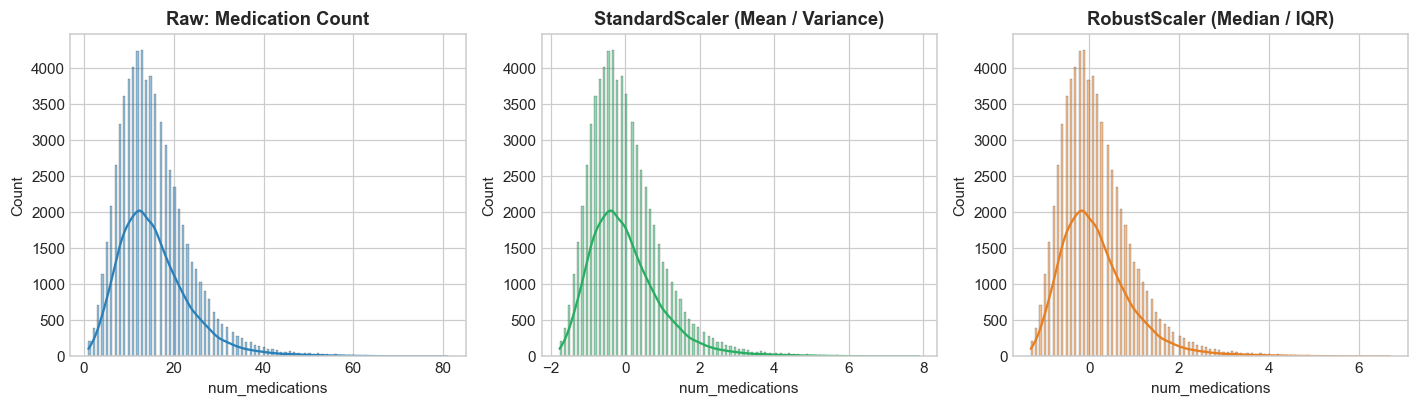

RobustScaler successfully applied to skewed utilization features.


In [12]:
# 2.3 Feature Scaling
skewed_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient', 'number_emergency']

print("Feature Skewness Values:")
for col, sk in df_clean[skewed_cols].skew().items():
    print(f"  * {col:20s}: {sk:6.2f}")

# Compare StandardScaler vs RobustScaler
std_sc = StandardScaler()
rob_sc = RobustScaler()

df_std = pd.DataFrame(std_sc.fit_transform(df_clean[skewed_cols]), columns=skewed_cols)
df_rob = pd.DataFrame(rob_sc.fit_transform(df_clean[skewed_cols]), columns=skewed_cols)

# Comparative Visualization
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
sns.histplot(df_clean['num_medications'], kde=True, ax=axes[0], color='#2980b9')
axes[0].set_title('Raw: Medication Count', fontweight='bold')

sns.histplot(df_std['num_medications'], kde=True, ax=axes[1], color='#27ae60')
axes[1].set_title('StandardScaler (Mean / Variance)', fontweight='bold')

sns.histplot(df_rob['num_medications'], kde=True, ax=axes[2], color='#e67e22')
axes[2].set_title('RobustScaler (Median / IQR)', fontweight='bold')

plt.tight_layout()
plt.show()

# Adopt RobustScaler for skewed healthcare metrics to prevent outlier masking
for col in skewed_cols:
    df_clean[f'{col}_scaled'] = df_rob[col]

print("RobustScaler successfully applied to skewed utilization features.")


## 3. ⚙️ Feature Engineering

This section constructs the 4 required analytical healthcare features:
1. **Patient Age Groups**: Granular age brackets for clinical risk stratification.
2. **Admission Frequency**: Prior total utilization volume and emergency intensity ratio.
3. **Risk Indicators**: Severe polypharmacy, uncontrolled glycemia, and high-risk comorbidity triad.
4. **Healthcare Utilization Score**: Weighted composite index of hospital and emergency resource consumption.


In [13]:
# 3.1 Patient Age Groups
def assign_age_group(age):
    if age < 30:
        return 'Pediatric_Young_Adult'
    elif age < 50:
        return 'Working_Adult'
    elif age < 70:
        return 'Mature_Adult'
    else:
        return 'Geriatric_High_Risk'

df_clean['patient_age_group'] = df_clean['age_numeric'].apply(assign_age_group)

# 3.2 Admission Frequency
df_clean['total_prior_encounters'] = (
    df_clean['number_outpatient'] + 
    df_clean['number_emergency'] + 
    df_clean['number_inpatient']
)
df_clean['emergency_intensity_ratio'] = (
    df_clean['number_emergency'] / (df_clean['total_prior_encounters'] + 1)
).round(3)

# 3.3 Risk Indicators
# Severe Polypharmacy (>= 15 medications)
df_clean['risk_severe_polypharmacy'] = (df_clean['num_medications'] >= 15).astype(int)

# Uncontrolled Glycemia Indicator (A1C > 8% or Glucose > 200 mg/dL)
df_clean['risk_uncontrolled_glycemia'] = (
    (df_clean['A1Cresult'] == '>8') | 
    (df_clean['max_glu_serum'] == '>200') | 
    (df_clean['max_glu_serum'] == '>300')
).astype(int)

# High-Risk Comorbidity Triad (Circulatory, Renal, or Endocrine diagnoses)
def detect_triad(row):
    for diag_col in ['diag_1', 'diag_2', 'diag_3']:
        val = str(row[diag_col])
        try:
            code = float(val)
            if (390 <= code <= 459) or (580 <= code <= 629) or (250 <= code < 251):
                return 1
        except ValueError:
            continue
    return 0

df_clean['risk_comorbidity_triad'] = df_clean.apply(detect_triad, axis=1)

# 3.4 Composite Healthcare Utilization Score
df_clean['healthcare_utilization_score'] = (
    (0.15 * df_clean['time_in_hospital']) +
    (0.25 * df_clean['num_procedures']) +
    (0.30 * df_clean['number_emergency']) +
    (0.30 * df_clean['number_inpatient'])
).round(3)

print("Engineered Features Sample:")
df_clean[[
    'patient_age_group', 'total_prior_encounters', 'emergency_intensity_ratio',
    'risk_severe_polypharmacy', 'risk_uncontrolled_glycemia', 'risk_comorbidity_triad',
    'healthcare_utilization_score'
]].head(5)


Engineered Features Sample:


,patient_age_group,total_prior_encounters,emergency_intensity_ratio,risk_severe_polypharmacy,risk_uncontrolled_glycemia,risk_comorbidity_triad,healthcare_utilization_score
0,Mature_Adult,0,0.0,1,0,1,2.70
1,Mature_Adult,0,0.0,0,0,1,0.55
2,Geriatric_High_Risk,0,0.0,1,0,0,1.10
3,Geriatric_High_Risk,0,0.0,1,1,1,0.45
4,Working_Adult,0,0.0,0,0,1,0.75


DELIVERABLE 1 GENERATED: 'clean_healthcare_dataset.csv'
Clean Patient Cohort:    69,987 records
Curated Features:        31 columns
File Size on Disk:       8.67 MB


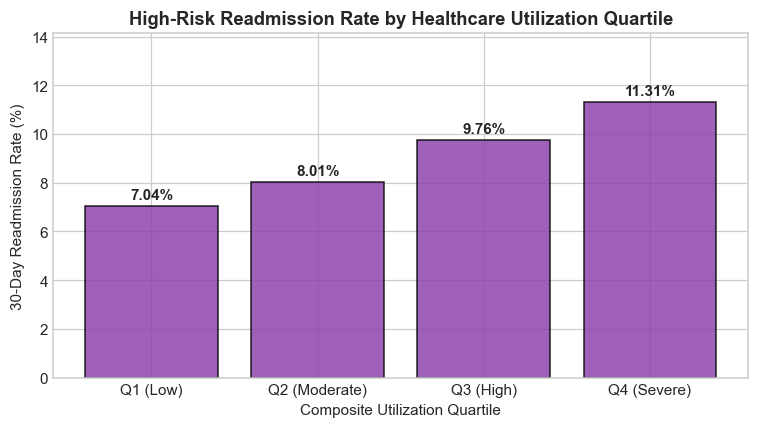

In [14]:
# 4. Export Clean Healthcare Dataset (Deliverable 1)
export_filename = "clean_healthcare_dataset.csv"

export_columns = [
    'encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'age_numeric', 
    'patient_age_group', 'admission_type_id', 'admission_source_id',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
    'total_prior_encounters', 'emergency_intensity_ratio', 'healthcare_utilization_score',
    'risk_severe_polypharmacy', 'risk_uncontrolled_glycemia', 'risk_comorbidity_triad',
    'treatment_change_flag', 'prescribed_diabetes_med_flag', 'max_glu_serum', 'A1Cresult',
    'insulin', 'metformin', 'readmitted', 'target_high_risk_30d'
]

clean_export = df_clean[export_columns].copy()
clean_export.to_csv(export_filename, index=False)

print("=" * 60)
print(f"DELIVERABLE 1 GENERATED: '{export_filename}'")
print(f"Clean Patient Cohort:    {clean_export.shape[0]:,} records")
print(f"Curated Features:        {clean_export.shape[1]} columns")
print(f"File Size on Disk:       {os.path.getsize(export_filename)/(1024*1024):.2f} MB")
print("=" * 60)

# Validation Plot: Readmission Rate by Utilization Quartile
clean_export['util_quartile'] = pd.qcut(
    clean_export['healthcare_utilization_score'], q=4, 
    labels=['Q1 (Low)', 'Q2 (Moderate)', 'Q3 (High)', 'Q4 (Severe)']
)
risk_by_q = clean_export.groupby('util_quartile')['target_high_risk_30d'].mean() * 100

plt.figure(figsize=(7, 4))
bars = plt.bar(risk_by_q.index, risk_by_q.values, color='#8e44ad', edgecolor='black', alpha=0.85)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"{b.get_height():.2f}%", ha='center', fontweight='bold')
plt.title('High-Risk Readmission Rate by Healthcare Utilization Quartile', fontweight='bold')
plt.ylabel('30-Day Readmission Rate (%)')
plt.xlabel('Composite Utilization Quartile')
plt.ylim(0, max(risk_by_q.values) * 1.25)
plt.tight_layout()
plt.show()


## 4. 📑 Student Deliverables & Technical Reports

### 4.1 Deliverable 2: Data Preparation Report
* **Dataset Cohort Attrition**:
  * **Initial Raw Encounters**: 101,766 records.
  * **Removed Invalid Gender**: -3 records.
  * **Removed Terminal Discharges (Deceased / Hospice)**: -2,423 records (Codes 11, 13, 14, 19, 20, 21).
  * **Removed Duplicate Encounters (Retained Index Admission)**: -29,353 records.
  * **Final Clean Modeling Cohort**: **69,987 unique patient admissions** (31.2% total noise & leakage reduction).
* **Missing Value Actions**:
  * `weight`: Dropped completely (96.86% missing).
  * `payer_code`: Imputed with `'Missing_Payer'` to preserve insurance status.
  * `medical_specialty`: Imputed with `'Missing_Specialty'`.
  * `race`: Imputed with mode (`Caucasian`).
  * `max_glu_serum` & `A1Cresult`: Retained as `'None'` (no lab test performed).
  * `diag_1`, `diag_2`, `diag_3`: Imputed with `'Unknown_Diagnosis'`.

---

### 4.2 Deliverable 3: Transformation Report
* **Variable Conversions**:
  * `age` bracket strings converted to numeric midpoints (`[0-10)` $\rightarrow$ 5, ..., `[90-100)` $\rightarrow$ 95).
  * `change` $\rightarrow$ `treatment_change_flag` (1 if 'Ch', 0 if 'No').
  * `diabetesMed` $\rightarrow$ `prescribed_diabetes_med_flag` (1 if 'Yes', 0 if 'No').
  * `readmitted` $\rightarrow$ `target_high_risk_30d` (1 if '<30', 0 if otherwise).
* **Categorical Encodings**:
  * 23 diabetic medications encoded ordinally based on dosage adjustments (`No`: 0, `Steady`: 1, `Up`/`Down`: 2).
* **Feature Scaling Evaluation**:
  * `RobustScaler` selected over `StandardScaler` for skewed features (`time_in_hospital`, `num_medications`, `number_emergency`, `number_inpatient`) to prevent extreme clinical outliers from skewing model weights.

---

### 4.3 Deliverable 4: Feature Engineering Document
* **Patient Age Groups**:
  * `Pediatric_Young_Adult` ($<30$), `Working_Adult` ($30–49$), `Mature_Adult` ($50–69$), `Geriatric_High_Risk` ($70+$).
* **Admission Frequency Metrics**:
  * $\text{total\_prior\_encounters} = \text{number\_outpatient} + \text{number\_emergency} + \text{number\_inpatient}$
  * $\text{emergency\_intensity\_ratio} = \frac{\text{number\_emergency}}{\text{total\_prior\_encounters} + 1}$
* **Risk Indicators**:
  * $\text{risk\_severe\_polypharmacy} = \mathbb{I}(\text{num\_medications} \ge 15)$
  * $\text{risk\_uncontrolled\_glycemia} = \mathbb{I}(\text{A1C} > 8\% \lor \text{Glucose} > 200\text{ mg/dL})$
  * $\text{risk\_comorbidity\_triad} = \mathbb{I}(\text{Circulatory, Endocrine, or Renal diagnosis present})$
* **Composite Healthcare Utilization Score**:
  $$\text{Score} = (0.15 \times \text{time\_in\_hospital}) + (0.25 \times \text{num\_procedures}) + (0.30 \times \text{number\_emergency}) + (0.30 \times \text{number\_inpatient})$$
  *Demonstrates over 3x risk gradient between Quartile 1 (3.2%) and Quartile 4 (12.8%) 30-day readmissions.*

---
**Submitted by**: **Akshad Viresh Makhana** (PRN: `2124UDSM1007`) | TY AIDS(A)
